In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# to do
import EDA_helper as hf

In [2]:
data_prefix = '../data_curation/processed_data/'
figure_prefix = '../figures/'


In [3]:
data = pd.read_parquet(data_prefix + 'final_dataset.parquet')
data

,SMILES,MP,Type,Ro5,RDKit_PEOE_VSA3,RDKit_NumAliphaticRings X RDKit_SlogP_VSA8,RDKit_NHOHCount,RDKit_SMR_VSA10 X RDKit_VSA_EState6,MACCS_105 X RDKit_NHOHCount,MACCS_105 X RDKit_fr_Ar_COO,...,MACCS_161,RDKit_NHOHCount X RDKit_SlogP_VSA8,RDKit_BertzCT X RDKit_RingCount,RDKit_fr_ArN,RDKit_SMR_VSA5,MACCS_126 X RDKit_NumHDonors,RDKit_MaxAbsPartialCharge,MACCS_155 X RDKit_fr_Ar_OH,RDKit_Chi3n X RDKit_NumRotatableBonds,RDKit_SlogP_VSA2
0,ON=Cc1cscc1,122.0,Train,1,0.000000,0.0,1,32.985231,0,0,...,1,0.0,168.564167,0,0.000000,0,0.410848,0,0.749989,11.421854
1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,205.5,Train,1,0.000000,0.0,1,0.000000,1,0,...,0,0.0,3553.423052,0,77.105125,0,0.392773,0,8.850244,34.482001
2,[O-][n+]1ccccc1,64.0,Train,1,0.000000,0.0,0,0.000000,0,0,...,1,0.0,138.007504,0,0.000000,0,0.618694,0,0.000000,0.000000
3,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,146.0,Train,1,0.000000,0.0,1,0.000000,1,0,...,0,0.0,2479.213445,0,111.854606,0,0.393120,0,55.138771,11.210494
4,CC(=O)c1ccc(cc1)Br,51.0,Train,1,0.000000,0.0,0,158.762615,0,0,...,0,0.0,237.939433,0,6.923737,0,0.294512,0,1.250748,5.783245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,226.0,Test,1,4.983979,0.0,0,1206.535383,0,0,...,1,0.0,5383.333235,0,0.000000,0,0.247117,0,0.000000,4.983979
17216,COc1cc(OC)cc(c1C#N)OC,142.0,Test,1,0.000000,0.0,0,0.000000,0,0,...,1,0.0,343.115240,0,0.000000,0,0.496479,0,5.480514,21.329393
17217,OCCCCCCCCCCc1ccccc1,36.0,Test,1,0.000000,0.0,1,0.000000,0,0,...,0,0.0,255.487506,0,57.787395,0,0.396377,0,32.163904,11.713409
17218,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,159.0,Test,1,0.000000,0.0,0,374.273871,0,0,...,0,0.0,3039.296866,0,18.628754,0,0.480231,0,0.000000,6.103966


In [4]:
non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']
feature_col = data.drop(non_feature_cols, axis = 1).columns

Selected top 15 features with strongest correlation to 'MP'
Heatmap saved to ../figures/correlation_heatmap.png


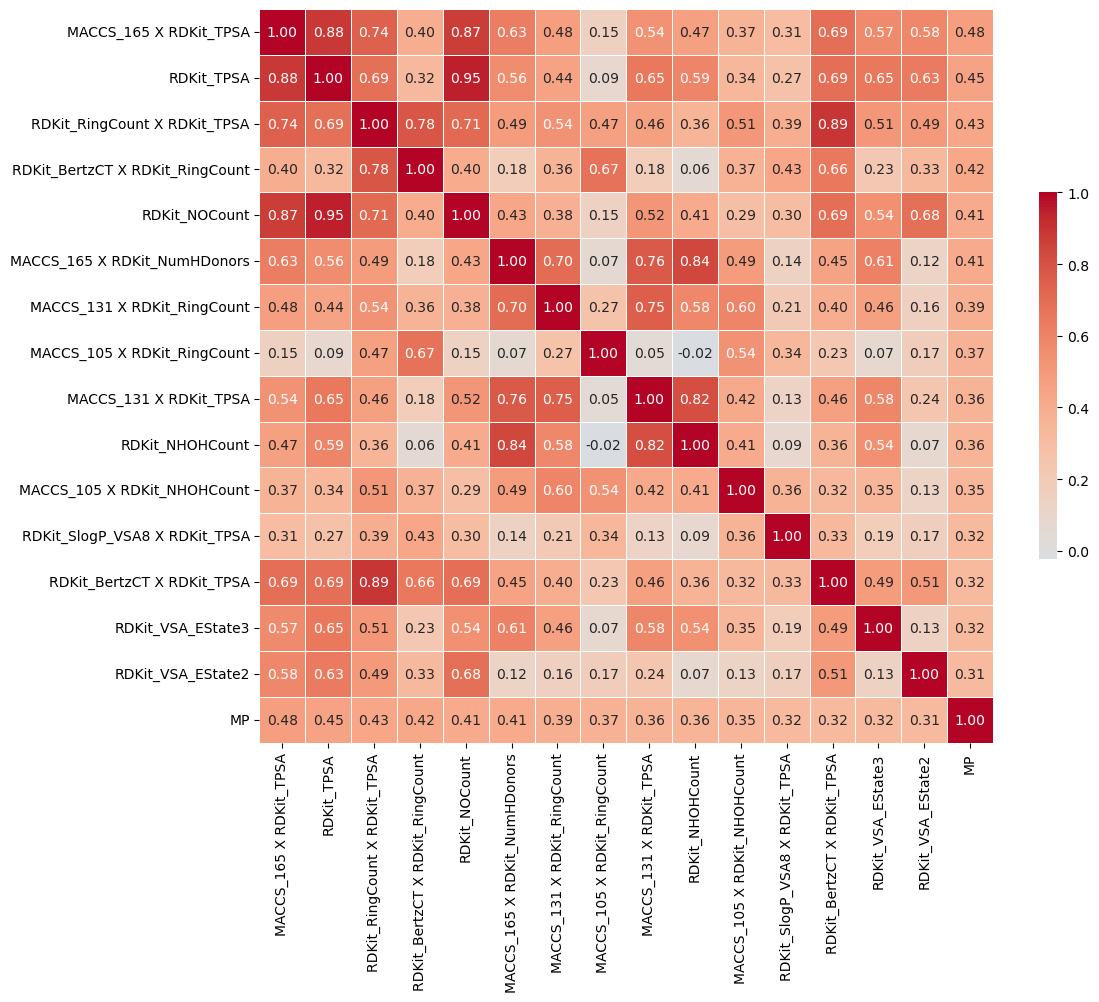

In [5]:
def plot_correlation_heatmap(features_df, target_df, save_path, top_n=None):

    # Combine features and target
    if isinstance(target_df, pd.Series):
        target_df = target_df.to_frame()
    
    target_col = target_df.columns[0]
    df_combined = pd.concat([features_df, target_df], axis=1)
    
    # Calculate correlation matrix
    corr_matrix = df_combined.corr()
    
    # Filter for top_n features correlated with target if specified
    if top_n is not None:
        # Get correlation with target, drop target itself to avoid self-correlation
        target_corr = corr_matrix[target_col].drop(target_col)
        
        # Get top n features by absolute correlation value
        top_features = target_corr.abs().sort_values(ascending=False).head(top_n).index.tolist()
        
        # Filter matrix to keep top features + target. Reorder so target is last or first for visibility
        cols_to_keep = top_features + [target_col]
        corr_matrix = corr_matrix.loc[cols_to_keep, cols_to_keep]
        
        print(f"Selected top {top_n} features with strongest correlation to '{target_col}'")
    
    # Set up the matplotlib figure
    plt.figure(figsize=(12, 10))
    
    # Draw the heatmap
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    
#    plt.title(f'Feature-Target Correlation Heatmap{" (Top " + str(top_n) + ")" if top_n else ""}')
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Heatmap saved to {save_path}")
    plt.show()

plot_correlation_heatmap(data[feature_col], data[['MP']], figure_prefix + 'correlation_heatmap.png', 15)

Calculating Ro5 properties...


/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_69873/423592716.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=data, x=x_col, y=y_col, palette=palette, ax=ax)
/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_69873/423592716.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=data, x=x_col, y=y_col, palette=palette, ax=ax)
/var/folders/4j/q1b8spls57ldz2j3g8k6nxh40000gn/T/ipykernel_69873/423592716.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=data, x=x_col, y=y_col, palette=palette, ax=ax

Plot saved to ../figures/properties_comparison.png


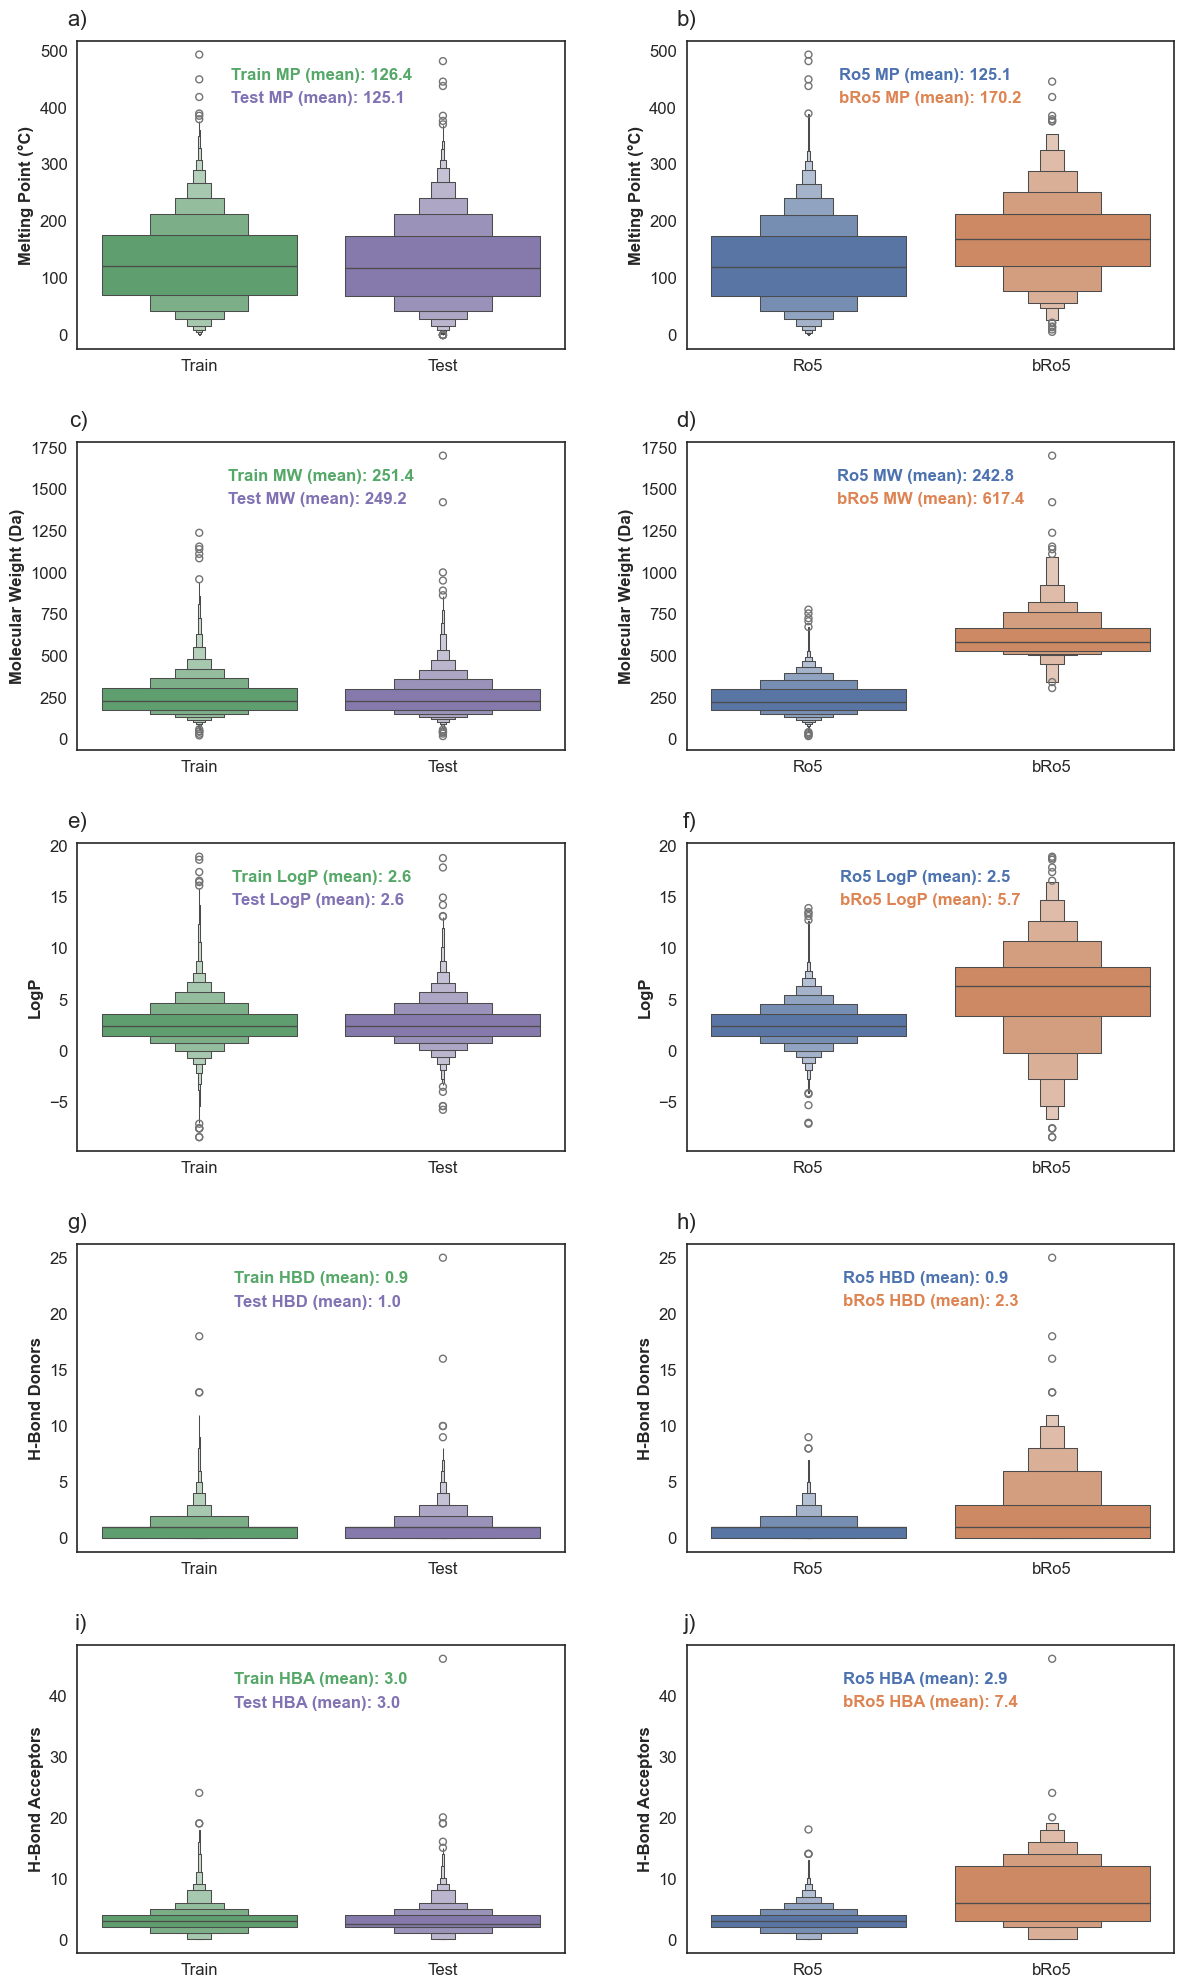

In [11]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import string

def plot_properties_comparison_violin(df, smiles_col, group1_col, group2_col, save_path):

    # --- Aesthetics Configuration ---
    # sns.set_style("whitegrid")
    plt.rcParams['font.family'] = 'Arial' 
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.linewidth'] = 1.2
    
    # Custom colors
    palette_g1 = {'Ro5': '#4c72b0', 'bRo5': '#dd8452'} 
    palette_g2 = {'Train': '#55a868', 'Test': '#8172b3', 
                  'train': '#55a868', 'test': '#8172b3'}

    df_plot = df.copy()
    
    # Map Ro5 labels
    if 'Ro5' in group1_col:
        df_plot['Group1_Label'] = df_plot[group1_col].map({1: 'Ro5', 0: 'bRo5', True: 'Ro5', False: 'bRo5'})
    else:
        df_plot['Group1_Label'] = df_plot[group1_col]
        
    df_plot['Group2_Label'] = df_plot[group2_col]
    
    print("Calculating Ro5 properties...")
    required_props = ['MW', 'LogP', 'HBD', 'HBA']
    if not all(col in df_plot.columns for col in required_props):
        mols = [Chem.MolFromSmiles(s) for s in df_plot[smiles_col]]
        valid_mask = [m is not None for m in mols]
        df_plot = df_plot[valid_mask].copy()
        mols = [m for m in mols if m is not None]
        
        df_plot['MW'] = [Descriptors.MolWt(m) for m in mols]
        df_plot['LogP'] = [Descriptors.MolLogP(m) for m in mols]
        df_plot['HBD'] = [Descriptors.NumHDonors(m) for m in mols]
        df_plot['HBA'] = [Descriptors.NumHAcceptors(m) for m in mols]
    
    properties = [
        ('MP', 'Melting Point (°C)'),
        ('MW', 'Molecular Weight (Da)'), 
        ('LogP', 'LogP'), 
        ('HBD', 'H-Bond Donors'), 
        ('HBA', 'H-Bond Acceptors')
    ]
    
    # Setup subplots: 5 rows (properties), 2 columns (groups)
    # Left: Group 2 (Train/Test), Right: Group 1 (Ro5/bRo5)
    fig, axes = plt.subplots(len(properties), 2, figsize=(12, 20))
    letters = string.ascii_lowercase
    letter_idx = 0

    def setup_subplot(ax, data, x_col, y_col, y_label, palette, letter):
        # Plot
        sns.boxenplot(data=data, x=x_col, y=y_col, palette=palette, ax=ax)
        
        # Labels
        ax.set_ylabel(y_label, fontweight='bold')
        ax.set_xlabel('')
        
        # Tag (a, b...) - Top left outside
        ax.text(0.02, 1.1, f"{letter})", transform=ax.transAxes, 
                fontsize=16,  va='top', ha='right')

        # Legend with Means
        means = data.groupby(x_col)[y_col].mean()
        
        # Determine order to match colors
        unique_groups = sorted(data[x_col].unique())
        # Enforce Ro5/bRo5 or Train/Test order if applicable
        if 'Ro5' in unique_groups and 'bRo5' in unique_groups:
             ordered_groups = ['Ro5', 'bRo5']
        elif 'Train' in unique_groups and 'Test' in unique_groups:
             ordered_groups = ['Train', 'Test']
        else:
             ordered_groups = unique_groups

        legend_handles = []
        legend_colors = []
        
        for grp in ordered_groups:
            if grp not in means.index: continue
            mu = means[grp]
            col = palette.get(grp, 'black')
            
            label_text = f"{grp} {y_col} (mean): {mu:.1f}"
            # Invisible patch for handle
            patch = mpatches.Patch(color='none', label=label_text)
            legend_handles.append(patch)
            legend_colors.append(col)
            
        # Place legend upper center, 2 rows (ncol=1), brought lower (inside plot at y=0.90)
        leg = ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.95),
                        ncol=1, frameon=False, 
                        handlelength=0, handletextpad=0, borderpad=0.2)
        
        # Color the text
        for txt, col in zip(leg.get_texts(), legend_colors):
            txt.set_color(col)
            txt.set_weight('bold')

    for i, (prop, label) in enumerate(properties):
        # Left Column: Group 2 (Train vs Test)
        ax_left = axes[i, 0]
        setup_subplot(ax_left, df_plot, 'Group2_Label', prop, label, palette_g2, letters[letter_idx])
        letter_idx += 1
        
        # Right Column: Group 1 (Ro5 vs bRo5)
        ax_right = axes[i, 1]
        setup_subplot(ax_right, df_plot, 'Group1_Label', prop, label, palette_g1, letters[letter_idx])
        letter_idx += 1

    fig.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.25)
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
    print(f"Plot saved to {save_path}")
    plt.show()

# Example usage
plot_properties_comparison_violin(data, 'SMILES', 'Ro5', 'Type', figure_prefix + 'properties_comparison.png')

Performing PCA...
PCA contour plot saved to ../figures/pca_joint_contour.png


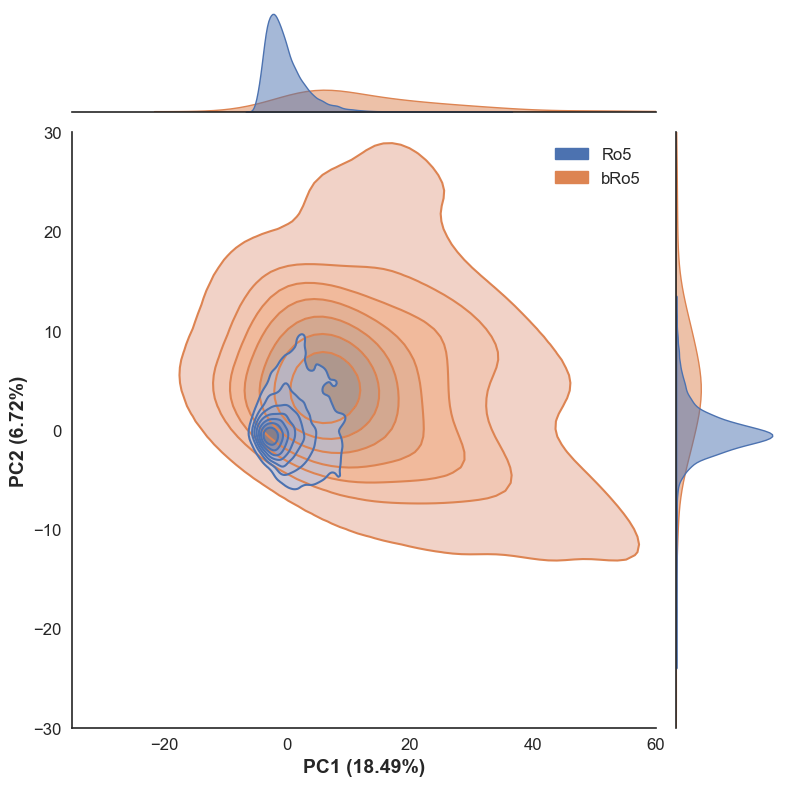

In [7]:
def plot_pca_joint_contour_only(df, features_df, hue_col, save_path, xlim=None, ylim=None):

    sns.set_style("white")
    plt.rcParams['font.family'] = 'Arial'

    cut = 3
    thresh = 0.05
    level = 8
    
    # Custom palette
    palette = {'Ro5': '#4c72b0', 'bRo5': '#dd8452', '1': '#4c72b0', '0': '#dd8452', 1: '#4c72b0', 0: '#dd8452'}
    
    print("Performing PCA...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features_df)
    
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X_scaled)
    explained_variance = pca.explained_variance_ratio_
    
    df_plot = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
    df_plot[hue_col] = df[hue_col].values
    
    # Robust Mapping
    df_plot['Label'] = df_plot[hue_col].astype(str).replace({
        '1': 'Ro5', '0': 'bRo5', 
        '1.0': 'Ro5', '0.0': 'bRo5',
        'True': 'Ro5', 'False': 'bRo5'
    })
    
    # 1. Initialize JointGrid
    # Set limits if provided
    g = sns.JointGrid(data=df_plot, x='PC1', y='PC2', hue='Label', palette=palette, 
                      height=8, ratio=5, space=0.2, xlim=xlim, ylim=ylim)
    
    # 2. Draw Marginals
    g.plot_marginals(sns.kdeplot, fill=True, common_norm=False, alpha=0.5, thresh = thresh, cut=cut) 
    
    # 3. Draw Joint Density MANUALLY to control Order
    # We want Ro5 on TOP of bRo5
    
    # Define group order: bRo5 first (bottom), Ro5 last (top)
    labels_order = ['bRo5', 'Ro5']
    
    for label in labels_order:
        subset = df_plot[df_plot['Label'] == label]
        if len(subset) < 2: continue
        
        color = palette.get(label, 'black')
        
        # Plot Fill
        sns.kdeplot(
            data=subset, x='PC1', y='PC2',
            ax=g.ax_joint, 
            color=color, 
            fill=True, alpha=0.6, 
            levels=level, thresh=thresh, cut=cut,
            common_norm=False
        )
        # Plot Lines (Edges)
        sns.kdeplot(
            data=subset, x='PC1', y='PC2',
            ax=g.ax_joint, 
            color=color, 
            fill=False, 
            levels=level, thresh=thresh, cut=cut, linewidths=1.5,
            common_norm=False
        )

    # Labels
    g.set_axis_labels(f'PC1 ({explained_variance[0]:.2%})', 
                      f'PC2 ({explained_variance[1]:.2%})', 
                      fontsize=14, fontweight='bold')
    
    # Manual Legend to ensure correct order/colors
    handles = [mpatches.Patch(color=palette['Ro5'], label='Ro5'),
               mpatches.Patch(color=palette['bRo5'], label='bRo5')]
    g.ax_joint.legend(handles=handles, title=None, loc='upper right', frameon=False)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
        print(f"PCA contour plot saved to {save_path}")
    plt.show()


plot_pca_joint_contour_only(data, data[feature_col], 'Ro5', figure_prefix + 'pca_joint_contour.png',xlim=(-35, 60), ylim=(-30, 30))